In [145]:
from lib.evaluate import Eva
from lib.utils import read_parameters

import numpy as np
import plotly.express as px
import bioframe as bf
from tqdm import tqdm
import pandas as pd
from datetime import datetime
from collections import defaultdict
import upsetplot
import matplotlib.pyplot as plt

# Functions

In [18]:
def plot_precision_recall_curve(df, svtype):
    """ Plot precision recall curve. 

    param pr_rc_df: pandas dataframe with precision and recall for different thresholds """

    pr_rc_df = df[df['type'] == svtype].copy().reset_index(drop=True)
    pr_rc_df['method'] = pr_rc_df['method'].replace({'dicast' : 'MGI dicast', 
                                                     'delly' : 'MGI delly',
                                                     'manta' : 'MGI manta',
                                                     'lumpy' : 'MGI lumpy',
                                                     'gridss' : 'MGI gridss',
                                                     'cnvnator' : 'MGI cnvnator',
                                                     'sniffles' : 'PB sniffles'})

    colors = ['#50514F', '#F25F5C', '#F9A061', '#FFE066', '#A9D2DB', '#247BA0', '#67A2A0', '#50514F', '#F25F5C', '#F9A061', '#FFE066', '#A9D2DB']
    dash = ['solid', 'solid', 'solid', 'solid', 'solid', 'solid', 'solid', 'dot', 'dot', 'dot', 'dot', 'dot']
    fig = px.line(x='recall', y='precision', color='method', 
                data_frame=pr_rc_df, 
                color_discrete_sequence=colors,
                line_dash='method',
                line_dash_sequence=dash)

    for i, method in enumerate(pr_rc_df['method'].unique()):
        x = pr_rc_df[pr_rc_df['method'] == method].reset_index(drop=True).loc[0, 'recall']
        y = pr_rc_df[pr_rc_df['method'] == method].reset_index(drop=True).loc[0, 'precision']
        fig.add_shape(type='circle', xref='x', yref='y', x0=x-0.003, y0=y-0.015, x1=x+0.0025, y1=y+0.002, line_color=colors[i], line_width=2, opacity=1, fillcolor='white')

    fig.update_layout(plot_bgcolor='white', xaxis_title='Recall', yaxis_title='Precision', xaxis_linecolor='black', yaxis_linecolor='black')
    fig.update_traces(line=dict(width=2))
    fig.update_xaxes(ticks='outside', tickcolor='black', tickwidth=1, ticklen=5, gridcolor='lightgray', gridwidth=0.5, range=[0, 1])
    fig.update_yaxes(ticks='outside', tickcolor='black', tickwidth=1, ticklen=5, gridcolor='lightgray', gridwidth=0.5, range=[0, 1])
    fig.show()

In [3]:
def extract_overlap_ids(df1, df2):
    """ Extracts SV IDs of overlapping variants
    
    param df1: pandas dataframe, first dataframe
    param df2: pandas dataframe, second dataframe 
    
    return pandas dataframe with overlapping SV IDs """

    df1['end'] = df1['end'].astype(int)
    df2['end'] = df2['end'].astype(int)
    
    closest_intervals = bf.closest(df1, df2=df2, suffixes=('_1','_2'), k=50) # k=10 to get all overlapping variants
    closest_intervals = closest_intervals.dropna(subset=['id_1', 'id_2']).reset_index(drop=True)
    closest_intervals['diff_start'] = abs(closest_intervals['start_1'] - closest_intervals['start_2'])
    closest_intervals['diff_end'] = abs(closest_intervals['end_1'] - closest_intervals['end_2'])
    closest_intervals['diff_size'] = closest_intervals.apply(lambda x: min([x['size_1'], x['size_2']]) / max([x['size_1'], x['size_2']]), axis=1)

    overlapping_svs = closest_intervals[(closest_intervals['diff_start'] < 500) & (closest_intervals['diff_end'] < 500) & (closest_intervals['diff_size'] > 0.7)].copy()

    return overlapping_svs.reset_index(drop=True)

# Script

In [4]:
params = read_parameters('params/giab/params_eva.json')

In [5]:
eva = Eva(params)
eva.read_benchmark_variants()
eva.correct_benchmark_variants()
eva.read_method_variants()
eva.read_dicast_variants()
eva.overlap_bench_dicast()
eva.overlap_bench_methods()
eva.filter_variants()
eva.create_multi_caller_support_table(methods=['delly', 'manta', 'lumpy', 'gridss', 'cnvnator'])
eva.compute_precision_recall_df()

In [29]:
eva.compute_precision_recall_df()

In [25]:
tmp = eva.precision_recall_df[eva.precision_recall_df['method'] != 'at least 5 callers (f)'].copy().reset_index(drop=True)
tmp = tmp[tmp['method'] != 'at least 4 callers (f)'].copy().reset_index(drop=True)

In [17]:
plot_precision_recall_curve(eva.precision_recall_df, 'DEL')

In [27]:
#eva.compute_precision_recall_df(filtered=True)

plot_precision_recall_curve(tmp, 'DEL')

In [43]:
pr_rc_dict = defaultdict(list)

for i in range(5):
    df = eva.variants_filtered['at least ' + str(i+1) + ' callers'].copy().reset_index(drop=True)
    tp = df[(df['confirmed'] == 1) & (df['qual'] > 0)].shape[0]
    fp = df[(df['confirmed'] == 0) & (df['qual'] > 0)].shape[0]
    fn = df[(df['confirmed'] == 1) & (df['qual'] == 0)].shape[0]

    precision = tp / (tp + fp)
    recall = tp / (tp + fn)

    pr_rc_dict['method'].append('at least ' + str(i+1) + ' callers')
    pr_rc_dict['precision'].append(precision)
    pr_rc_dict['recall'].append(recall)

pr_rc_df = pd.DataFrame(pr_rc_dict)

In [45]:
pr_rc_df_long = pr_rc_df.melt(id_vars='method', value_vars=['precision', 'recall'], 
                  var_name='Metric', value_name='Value')

In [62]:
fig = px.bar(pr_rc_df_long, x='method', y='Value', color='Metric', barmode='group', color_discrete_sequence=['#F9A061', '#A9D2DB'])
fig.update_layout(plot_bgcolor='white')
fig.update_layout(yaxis=dict(showgrid=True, gridcolor='lightgray'))
fig.update_layout(bargap=0.5, width=800)
fig.show()

In [72]:
dicast_conf = eva.variants['dicast'][eva.variants['dicast']['confirmed'] == 1].copy().reset_index(drop=True)
dicast_conf = dicast_conf.explode('id_dicast')['id_dicast'].unique().tolist()[:-1]

In [86]:
for method in eva.variants_dicast['method'].unique():
    method_df = eva.variants_dicast[eva.variants_dicast['method'] == method].copy().reset_index(drop=True)
    method_df['confirmed'] = 0
    method_df.loc[method_df['id'].isin(dicast_conf), 'confirmed'] = 1
    mask_conf = (method_df['confirmed'] == 1) & (method_df['qual_dicast'] > 0.4) & (method_df['filter'] != 'PASS')
    mask_not_conf = (method_df['confirmed'] == 0) & (method_df['qual_dicast'] > 0.4) & (method_df['filter'] != 'PASS')
    print(method, method_df[mask_conf].shape[0], method_df[mask_not_conf].shape[0])

delly 91 34
manta 296 17
lumpy 0 0
gridss 1499 218
cnvnator 0 0


In [82]:
for method in eva.variants_dicast['method'].unique():
    method_df = eva.variants_dicast[eva.variants_dicast['method'] == method].copy().reset_index(drop=True)
    method_df['confirmed'] = 0
    method_df.loc[method_df['id'].isin(dicast_conf), 'confirmed'] = 1
    mask_conf = (method_df['confirmed'] == 1) & (method_df['qual_dicast'] > 0.4) & (method_df['filter'] != 'PASS')
    mask_not_conf = (method_df['confirmed'] == 0) & (method_df['qual_dicast'] > 0.4) & (method_df['filter'] != 'PASS')
    print(method, method_df[mask_conf].shape[0], method_df[mask_not_conf].shape[0])

,id_org,sample,tech,method,type,chrom,chrom2,start,end,size,filter,qual,pred_dicast,qual_dicast,id,confirmed
0,cnvnator.DEL.2,HG002,mgi,cnvnator,DEL,chr1,NaN,51001,108000,56999.0,PASS,NaN,0,0.00,dicast.DEL.71612,0
1,cnvnator.DEL.3,HG002,mgi,cnvnator,DEL,chr1,NaN,208001,258000,49999.0,PASS,NaN,0,0.01,dicast.DEL.71613,0
2,cnvnator.DEL.4,HG002,mgi,cnvnator,DEL,chr1,NaN,298001,348000,49999.0,PASS,NaN,0,0.04,dicast.DEL.71614,0
3,cnvnator.DEL.5,HG002,mgi,cnvnator,DEL,chr1,NaN,533001,586000,52999.0,PASS,NaN,0,0.00,dicast.DEL.71615,0
4,cnvnator.DEL.6,HG002,mgi,cnvnator,DEL,chr1,NaN,1139001,1142000,2999.0,PASS,NaN,0,0.02,dicast.DEL.71616,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2209,cnvnator.DEL.2254,HG002,mgi,cnvnator,DEL,chrX,NaN,151912001,151921000,8999.0,PASS,NaN,0,0.01,dicast.DEL.73821,0
2210,cnvnator.DEL.2255,HG002,mgi,cnvnator,DEL,chrX,NaN,152118001,152121000,2999.0,PASS,NaN,0,0.10,dicast.DEL.73822,0
2211,cnvnator.DEL.2256,HG002,mgi,cnvnator,DEL,chrX,NaN,154637001,154647000,9999.0,PASS,NaN,0,0.03,dicast.DEL.73823,0
2212,cnvnator.DEL.2257,HG002,mgi,cnvnator,DEL,chrX,NaN,155370001,155372000,1999.0,PASS,NaN,0,0.02,dicast.DEL.73824,0


In [88]:
eva.variants['delly']

,id,chrom,start,end,type,size,confirmed,qual,filter,id_method
0,chr1-DEL-100922995-100923315-320,chr1,100922995,100923315,DEL,320,1,0.028615,[PASS],[delly.DEL.346]
1,chr1-DEL-101157208-101157578-370,chr1,101157208,101157578,DEL,370,1,0.036246,[PASS],[delly.DEL.347]
2,chr1-DEL-101253202-101253276-74,chr1,101253202,101253276,DEL,74,1,0.011446,[PASS],[delly.DEL.349]
3,chr1-DEL-101258573-101258651-78,chr1,101258573,101258651,DEL,78,1,0.05723,[PASS],[delly.DEL.350]
4,chr1-DEL-102582122-102582452-330,chr1,102582122,102582452,DEL,330,1,0.05723,[PASS],[delly.DEL.352]
...,...,...,...,...,...,...,...,...,...,...
16622,delly.DEL.11058,chrX,151866512,151866549,DEL,37.0,0,0.014308,[PASS],[delly.DEL.11058]
16623,delly.DEL.11059,chrX,153091584,153091618,DEL,34.0,0,0.008585,[PASS],[delly.DEL.11059]
16624,delly.DEL.11061,chrX,154598641,155803682,DEL,1205041.0,0,0.002146,[LowQual],[delly.DEL.11061]
16625,delly.DEL.11063,chrX,155641814,155958697,DEL,316883.0,0,0.013449,[PASS],[delly.DEL.11063]


In [128]:
methods = ['delly', 'manta', 'lumpy', 'gridss', 'cnvnator']
result_dict = defaultdict(list)
for i in range(len(methods)):
    for j in range(i+1, len(methods)):
        method1 = methods[i]
        method2 = methods[j]
        mask_int = (eva.df_multi[method1] != 0) & (eva.df_multi[method2] != 0)
        mask_un = (eva.df_multi[method1] != 0) | (eva.df_multi[method2] != 0)
        
        for method in methods:
            result_dict[method].append(False)
        result_dict[method1][-1] = True
        result_dict[method2][-1] = True
        result_dict['jaccard'].append(eva.df_multi[mask_int].shape[0] / eva.df_multi[mask_un].shape[0])

In [152]:
pd.DataFrame(result_dict).set_index(['delly', 'manta', 'lumpy', 'gridss', 'cnvnator'])['jaccard']

delly  manta  lumpy  gridss  cnvnator
True   True   False  False   False       0.325376
       False  True   False   False       0.382053
              False  True    False       0.333071
                     False   True        0.026153
False  True   True   False   False       0.316365
              False  True    False       0.303152
                     False   True        0.022619
       False  True   True    False       0.325581
                     False   True        0.026178
              False  True    True        0.021903
Name: jaccard, dtype: float64

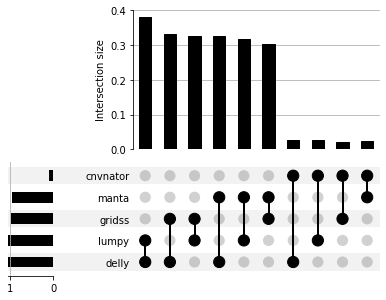

In [154]:
from upsetplot import plot
plot(pd.DataFrame(result_dict).set_index(['delly', 'manta', 'lumpy', 'gridss', 'cnvnator'])['jaccard'])  
plt.savefig('upset.png', dpi=300, bbox_inches='tight')

In [140]:
pd.DataFrame(result_dict).set_index(['delly', 'manta', 'lumpy', 'gridss', 'cnvnator'])

jaccard
delly manta lumpy gridss cnvnator          
True  True  False False  False     0.325376
      False True  False  False     0.382053
            False True   False     0.333071
                  False  True      0.026153
False True  True  False  False     0.316365
            False True   False     0.303152
                  False  True      0.022619
      False True  True   False     0.325581
                  False  True      0.026178
            False True   True      0.021903

In [107]:
m = ['delly', 'manta', 'lumpy', 'gridss', 'cnvnator']
tmp = eva.df_multi[(eva.df_multi[m] > 0).sum(axis=1) == 1]
unique_calls = dict()
for method in m:
    df_method = tmp[tmp[method] > 0].copy().reset_index(drop=True)
    #df_method = df_method.merge(eva.variants_dicast[['id_org', 'filter', 'qual_dicast']], left_on='id', right_on='id_org', how='left')
    unique_calls[method] = df_method['id']

In [109]:
unique_calls['delly']

0          chr1-DEL-91169315-91169373-58
1        chr1-DEL-154381021-154381074-53
2       chr1-DEL-194381376-194382116-740
3       chr1-DEL-207119028-207119764-736
4       chr1-DEL-236756278-236757158-880
                      ...               
2145                   cnvnator.DEL.2254
2146                   cnvnator.DEL.2255
2147                   cnvnator.DEL.2256
2148                   cnvnator.DEL.2257
2149                   cnvnator.DEL.2259
Name: id, Length: 2150, dtype: object

In [112]:
tmp[tmp['manta'] > 0]

,id,chrom,start,end,type,size,confirmed,delly,manta,lumpy,gridss,cnvnator
3,chr1-DEL-992993-993046-53,chr1,992993,993046,DEL,53,1,0,0.108108,0,0,0
11,chr1-DEL-1651421-1651474-53,chr1,1651421,1651474,DEL,53,1,0,0.580581,0,0,0
12,chr1-DEL-1666974-1667141-167,chr1,1666974,1667141,DEL,167,1,0,1.0,0,0,0
30,chr1-DEL-2859237-2859315-78,chr1,2859237,2859315,DEL,78,1,0,0.268268,0,0,0
32,chr1-DEL-2960007-2960127-120,chr1,2960007,2960127,DEL,120,1,0,0.998999,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
12859,cnvnator.DEL.2254,chrX,151912001,151921000,DEL,8999.0,0,0,1.0,0,0,0
12860,cnvnator.DEL.2255,chrX,152118001,152121000,DEL,2999.0,0,0,1.0,0,0,0
12861,cnvnator.DEL.2256,chrX,154637001,154647000,DEL,9999.0,0,0,1.0,0,0,0
12862,cnvnator.DEL.2257,chrX,155370001,155372000,DEL,1999.0,0,0,1.0,0,0,0


In [114]:
eva.df_multi

,id,chrom,start,end,type,size,confirmed,delly,manta,lumpy,gridss,cnvnator
0,chr1-DEL-909169-909480-311,chr1,909169,909480,DEL,311,1,0,0,0,0,0
1,chr1-DEL-934064-934876-812,chr1,934064,934876,DEL,812,1,0.059996,0.361361,0.159532,0,0
2,chr1-DEL-964631-964706-75,chr1,964631,964706,DEL,75,1,0,0,0,0,0
3,chr1-DEL-992993-993046-53,chr1,992993,993046,DEL,53,1,0,0.108108,0,0,0
4,chr1-DEL-1076227-1076645-418,chr1,1076227,1076645,DEL,418,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
19319,lumpy.DEL.329,chr2,88130322,88130633,DEL,311.0,0,0.0,0.0,0.103038,0.010696,0.0
19320,lumpy.DEL.422,chr2,178443386,178444420,DEL,1034.0,0,0.0,0.0,0.038222,0.012407,0.0
19321,lumpy.DEL.873,chr4,114586665,114589884,DEL,3219.0,0,0.0,0.0,0.034545,0.009805,0.0
19322,lumpy.DEL.1045,chr5,44514128,44517787,DEL,3659.0,0,0.0,0.0,0.053647,0.009264,0.0
